# **Part 08**
# **Parameter-Sensitivity Analysis of the Nernst Planck Model**

## **Overview**

Part 8 evaluates how three model parameters influence ion transport, neutralization, and the final pH distribution:

| Parameter | Low | Baseline | High |
|---|---:|---:|---:|
| Applied voltage, $V$ | $0.05\ \mathrm{V}$ | $0.10\ \mathrm{V}$ | $0.15\ \mathrm{V}$ |
| Electrode flux, $q$ | $1.0\times10^{-5}$ | $2.0\times10^{-5}$ | $3.0\times10^{-5}$ |
| Reaction-rate constant, $k$ | $25$ | $50$ | $75$ |

A **one-parameter-at-a-time (OAT)** method is used: one parameter is varied while the other two remain fixed at their baseline values. This isolates the effect of each parameter on the model response.

## **Evaluation Metrics**

Each simulation is compared using:

- minimum and maximum final pH;
- final total $\mathrm{H}^{+}$ and $\mathrm{OH}^{-}$ concentrations;
- cumulative neutralization;
- concentration positivity;
- ion mass-balance error;
- final two-dimensional pH distribution.

The pH range is defined as

$$
\Delta \mathrm{pH}=\mathrm{pH}_{\max}-\mathrm{pH}_{\min}.
$$

The final total ion concentration is calculated as

$$
C_{\mathrm{ions}}(T)
=\mathbf{1}^{T}M_L\mathbf{h}(T)
+\mathbf{1}^{T}M_L\mathbf{o}(T),
$$

where $M_L$ is the lumped mass matrix, while $\mathbf{h}$ and $\mathbf{o}$ represent the nodal concentrations of hydrogen and hydroxide ions.

For the neutralization reaction

$$
R=k\,c_{\mathrm{H}^{+}}c_{\mathrm{OH}^{-}},
$$

the cumulative reaction is

$$
S(T)=\sum_{n=0}^{N_t-1}\Delta t\,\mathbf{1}^{T}M_L\mathbf{r}^{n}.
$$

Because each reaction consumes one $\mathrm{H}^{+}$ ion and one $\mathrm{OH}^{-}$ ion, the total amount of neutralized ions is $2S(T)$.

## **Key Results**

### **Applied Voltage**

Electric field and charge-dependent ion migration increase with voltage. This increases the overlap of ions and the total neutralization, and reduces the number of ions remaining at the final time. In the simulations, the cumulative reaction increased from $\sim$2.94$ \times$10$^{-4}$ at 0.05 V to 5.81$ \times$10$^{-4}$ at 0.15 V.

### **Electrode Flux**

Increasing the electrode flux results in the introduction of more ions in the domain and in stronger acidic and basic regions. The minimum pH value decreased from $\sim 1.845$ to $\sim 1.368$ and the maximum pH value increased from $\sim 10.650$ to $12.758$. Thus the electrode flux exerts the greatest influence on the magnitude of the final pH change.

### **Reaction-Rate Constant**

As $k$ increases, the amount of ions in the overlap region decreases and the neutralization increases. The minimum pH was about $1.544$, but the maximum pH increased from about $10.349$ at $k=25$ to $12.934$ at $k=75$. This implies that the reaction rate is more important in the hydrogen-limited, hydroxide-rich regions.

## **Computational Procedure**

1. Define baseline, low, and high parameter values.
2. Run the complete ion-transport model for each case.
3. Vary only one parameter in each sensitivity study.
4. Compute the pH range, final ion concentrations, and cumulative neutralization.
5. Verify concentration positivity and ion mass balance.
6. Generate sensitivity curves and compare the final two-dimensional pH maps.

## **Numerical Verification**

Every simulation must satisfy

$$
c_{\min}\geq-10^{-12}
$$

and

$$
E_{\mathrm{balance}}^{\max}<10^{-10}.
$$

These checks confirm that the observed sensitivity trends are based on stable, mass-conservative, and physically admissible numerical solutions.

## **Conclusion**

The analysis shows different roles of the three parameters:

- **electrode flux** is the main determinant of the pH extremes;
- **applied voltage** controls the ionic migration, mixing and cumulative neutralization;
- **reaction rate** governs the neutralization of hydrogen and hydroxide ions in the overlap region.

This study reinforces the model with numerical robustness over a range of parameter values and provides a basis for calibration, treatment-design studies, optimization and uncertainty analysis.

## **Limitation**

The single-parameter sensitivity approach allows a direct evaluation of the individual contribution of each parameter, but ignores the interaction between parameters. Future work might include multi-parameter studies, global sensitivity analysis, uncertainty quantification, and parameter estimation from experimental data.data. The tested values are modelling parameters and should not be interpreted as experimentally validated treatment conditions.



Part 8: Parameter-Sensitivity Analysis
Number of nodes: 169
Number of elements: 288
Number of time steps per simulation: 2400
Global FEM matrices assembled successfully.
Total mesh area: 1.0

Sensitivity study for Applied voltage
Applied voltage : 0.05 | minimum pH: 1.4746380560038537 | maximum pH: 12.2267059925589 | cumulative reaction: 0.0002936897921643713
Applied voltage : 0.1 | minimum pH: 1.5436740806923492 | maximum pH: 11.96386147131693 | cumulative reaction: 0.00042487649469486523
Applied voltage : 0.15 | minimum pH: 1.6107056219969158 | maximum pH: 11.68771429175202 | cumulative reaction: 0.0005814515862293024

Sensitivity study for Electrode flux
Electrode flux : 1e-05 | minimum pH: 1.844708233128665 | maximum pH: 10.649779972542303 | cumulative reaction: 0.00020403657730315767
Electrode flux : 2e-05 | minimum pH: 1.5436740806923492 | maximum pH: 11.96386147131693 | cumulative reaction: 0.00042487649469486523
Electrode flux : 3e-05 | minimum pH: 1.3675809564199004 | maximum

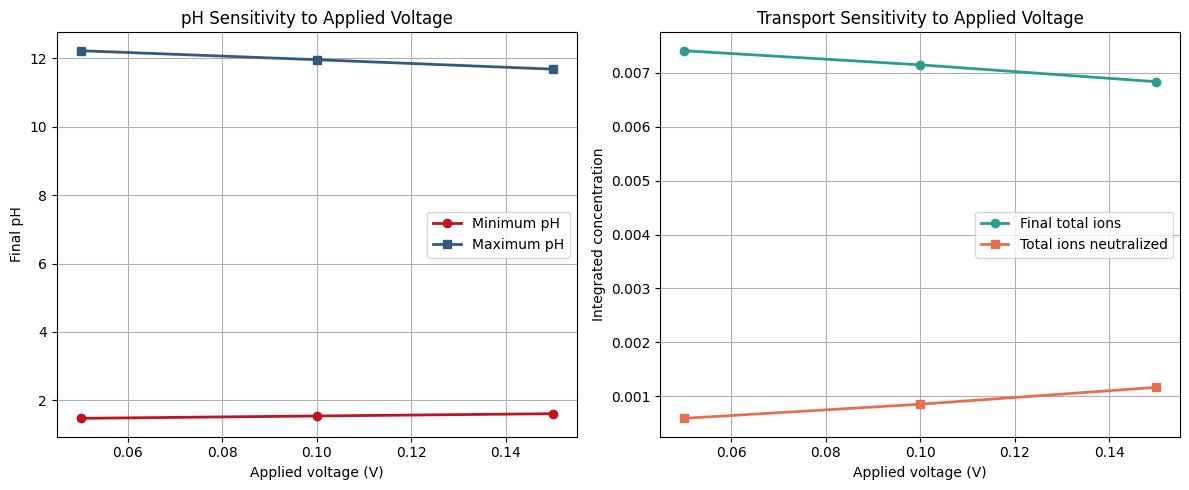

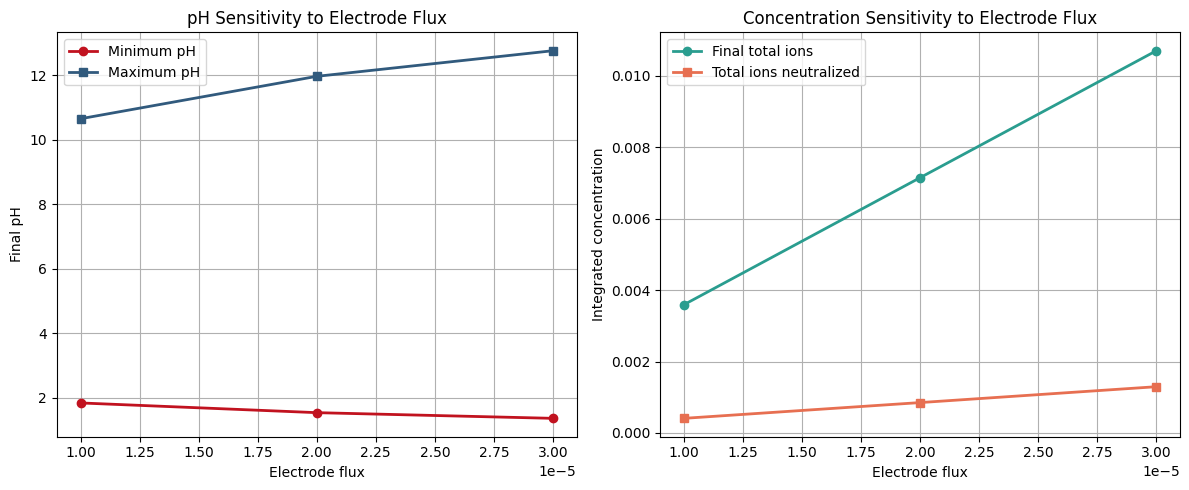

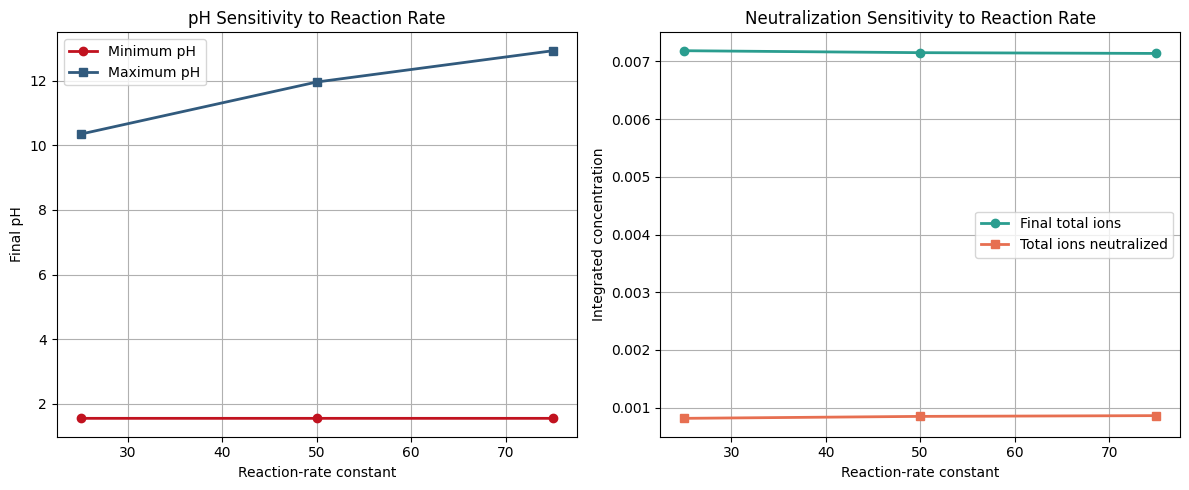

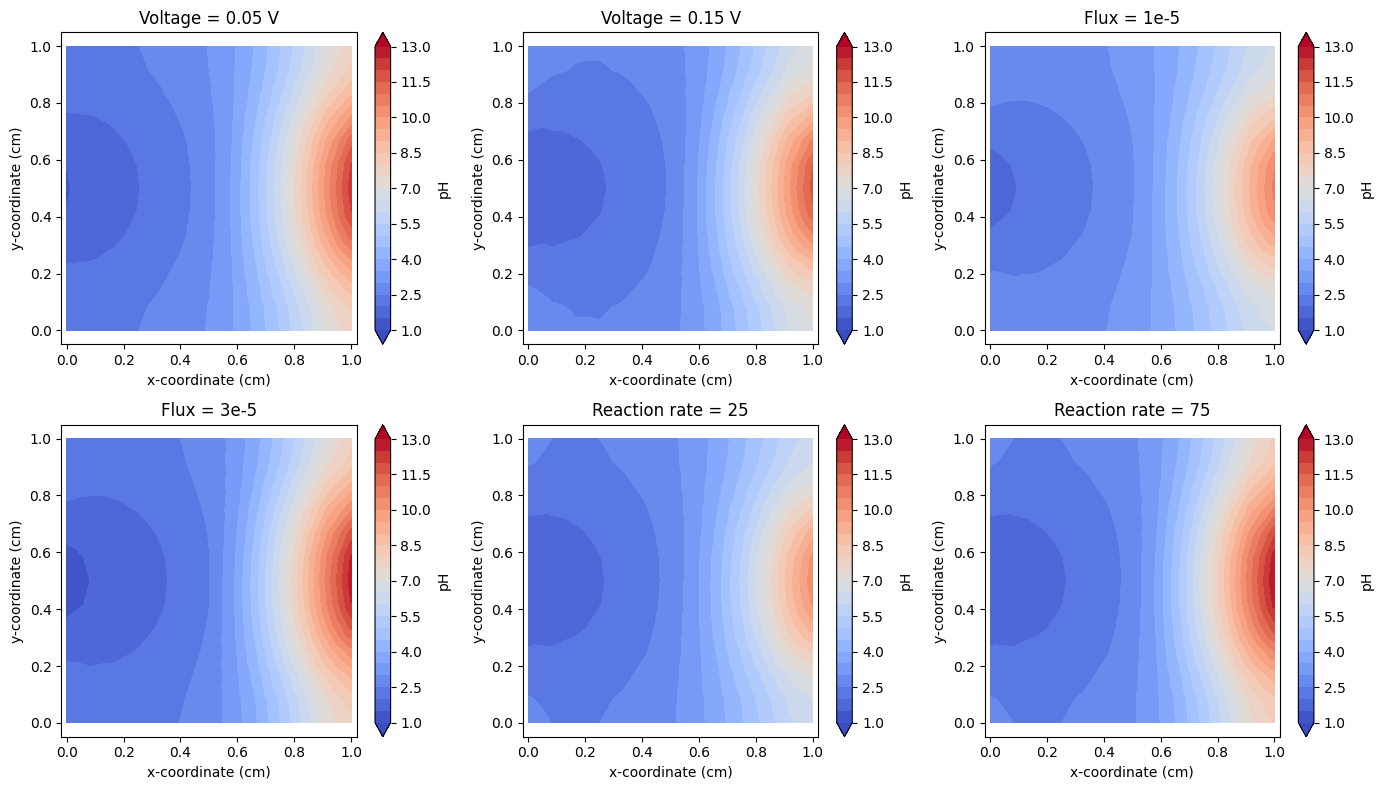

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
np.set_printoptions(precision=8,suppress=True)
# Domain and mesh parameters
Lx = 1.0
Ly = 1.0
Nx = 12
Ny = 12
x = np.linspace(0.0,Lx,Nx + 1)
y = np.linspace(0.0,Ly,Ny + 1)
X, Y = np.meshgrid(x,y,indexing="xy")
nodes = np.column_stack((X.ravel(),Y.ravel()))
# Generate triangular-element connectivity
elements = []
for j in range(Ny):
    for i in range(Nx):
        n1 = j*(Nx + 1) + i
        n2 = n1 + 1
        n3 = n1 + (Nx + 1)
        n4 = n3 + 1
        elements.append([n1,n2,n4])
        elements.append([n1,n4,n3])
elements = np.asarray(elements,dtype=int)
number_of_nodes = len(nodes)
number_of_elements = len(elements)
D_hydrogen = 9.31e-5
D_hydroxide = 5.27e-5
initial_neutral_concentration = 1.0e-7
faraday_constant = 96485.0
gas_constant = 8.314
absolute_temperature = 298.15
hydrogen_charge = 1.0
hydroxide_charge = -1.0
cathode_potential = 0.0
electric_coupling = faraday_constant/(gas_constant*absolute_temperature)
# Baseline parameters
baseline_voltage = 0.10
baseline_flux = 2.0e-5
baseline_reaction_rate = 50.0
# Time parameters
initial_time = 0.0
final_time = 600.0
time_step = 0.25
number_of_time_steps = int(round((final_time-initial_time)/time_step))
print("\nPart 8: Parameter-Sensitivity Analysis")
print("Number of nodes:",number_of_nodes)
print("Number of elements:",number_of_elements)
print("Number of time steps per simulation:",number_of_time_steps)
# Initialize global FEM matrices
global_mass = np.zeros((number_of_nodes,number_of_nodes))
global_stiffness = np.zeros((number_of_nodes,number_of_nodes))
# Arrays for element information
element_areas = np.zeros(number_of_elements)
element_basis_gradients = np.zeros((number_of_elements,3,2))
# Assemble FEM matrices
for element_index in range(number_of_elements):
    element = elements[element_index]
    coordinates = nodes[element]
    x1, y1 = coordinates[0]
    x2, y2 = coordinates[1]
    x3, y3 = coordinates[2]
    area = 0.5*((x2-x1)*(y3-y1)-(x3-x1)*(y2-y1))
    if area <= 0.0:
        raise ValueError("A reversed or degenerate element was found.")
    b_coefficients = np.array([y2-y3,y3-y1,y1-y2])
    c_coefficients = np.array([x3-x2,x1-x3,x2-x1])
    basis_gradients = np.column_stack((b_coefficients,c_coefficients))/(2.0*area)
    local_mass = (area/12.0)*np.array([
        [2.0,1.0,1.0],
        [1.0,2.0,1.0],
        [1.0,1.0,2.0]])
    local_stiffness = area*(basis_gradients @ basis_gradients.T)
    element_areas[element_index] = area
    element_basis_gradients[element_index] = basis_gradients
    for local_i in range(3):
        global_i = element[local_i]
        for local_j in range(3):
            global_j = element[local_j]
            global_mass[global_i,global_j] += local_mass[local_i,local_j]
            global_stiffness[global_i,global_j] += local_stiffness[local_i,local_j]
# Construct lumped mass matrix
lumped_mass_values = np.sum(global_mass,axis=1)
lumped_mass = np.diag(lumped_mass_values)
constant_vector = np.ones(number_of_nodes)
print("Global FEM matrices assembled successfully.")
print("Total mesh area:",element_areas.sum())
# Verify mesh and mass matrix
assert np.isclose(element_areas.sum(),Lx*Ly), "The total mesh area is incorrect."
assert np.all(element_areas > 0.0), "A non-positive element area was found."
assert np.all(lumped_mass_values > 0.0), "A non-positive lumped mass was found."
assert np.max(np.abs(global_mass-global_mass.T)) < 1.0e-12, "The mass matrix is not symmetric."
assert np.max(np.abs(global_stiffness-global_stiffness.T)) < 1.0e-12, "The stiffness matrix is not symmetric."
# Identify electric-potential boundary nodes
left_boundary_nodes = np.flatnonzero(np.isclose(nodes[:, 0],0.0))
right_boundary_nodes = np.flatnonzero(np.isclose(nodes[:, 0],Lx))
potential_boundary_nodes = np.concatenate((
    left_boundary_nodes,
    right_boundary_nodes))
free_potential_nodes = np.setdiff1d(
    np.arange(number_of_nodes),
    potential_boundary_nodes)
# Electrode boundary weights
hydrogen_flux_weights = np.zeros(number_of_nodes)
hydroxide_flux_weights = np.zeros(number_of_nodes)
electrode_y_minimum = 1.0/3.0
electrode_y_maximum = 2.0/3.0
for j in range(Ny):
    y_bottom = y[j]
    y_top = y[j + 1]
    edge_midpoint = 0.5*(y_bottom+y_top)
    edge_length = y_top-y_bottom
    if electrode_y_minimum <= edge_midpoint <= electrode_y_maximum:
        left_bottom = j*(Nx + 1)
        left_top = (j + 1)*(Nx + 1)
        right_bottom = j*(Nx + 1) + Nx
        right_top = (j + 1)*(Nx + 1) + Nx
        hydrogen_flux_weights[left_bottom] += edge_length/2.0
        hydrogen_flux_weights[left_top] += edge_length/2.0
        hydroxide_flux_weights[right_bottom] += edge_length/2.0
        hydroxide_flux_weights[right_top] += edge_length/2.0

def calculate_pH(hydrogen_values):
    safe_hydrogen = np.maximum(hydrogen_values,1.0e-14)
    return -np.log10(safe_hydrogen)

def run_simulation(applied_voltage, electrode_flux, reaction_rate_constant, store_final_solution=False):
    # Solve the electric-potential equation
    electric_potential = np.zeros(number_of_nodes)
    electric_potential[left_boundary_nodes] = applied_voltage
    electric_potential[right_boundary_nodes] = cathode_potential
    potential_right_hand_side = -global_stiffness[np.ix_(free_potential_nodes,potential_boundary_nodes)] @ electric_potential[potential_boundary_nodes]
    electric_potential[free_potential_nodes] = np.linalg.solve(
        global_stiffness[np.ix_(free_potential_nodes,free_potential_nodes)],
        potential_right_hand_side)
    # Initialize migration matrices
    hydrogen_migration = np.zeros((number_of_nodes,number_of_nodes))
    hydroxide_migration = np.zeros((number_of_nodes,number_of_nodes))
    # Assemble migration matrices
    for element_index in range(number_of_elements):
        element = elements[element_index]
        area = element_areas[element_index]
        basis_gradients = element_basis_gradients[element_index]
        potential_gradient = electric_potential[element] @ basis_gradients
        electric_field = -potential_gradient
        hydrogen_velocity = hydrogen_charge*D_hydrogen*electric_coupling*electric_field
        hydroxide_velocity = hydroxide_charge*D_hydroxide*electric_coupling*electric_field
        local_hydrogen_migration = -(area/3.0)*np.outer(basis_gradients @ hydrogen_velocity,np.ones(3))
        local_hydroxide_migration = -(area/3.0)*np.outer(basis_gradients @ hydroxide_velocity,np.ones(3))
        for local_i in range(3):
            global_i = element[local_i]
            for local_j in range(3):
                global_j = element[local_j]
                hydrogen_migration[global_i,global_j] += local_hydrogen_migration[local_i,local_j]
                hydroxide_migration[global_i,global_j] += local_hydroxide_migration[local_i,local_j]
    # Construct electrode-flux vectors
    hydrogen_flux_vector = electrode_flux*hydrogen_flux_weights
    hydroxide_flux_vector = electrode_flux*hydroxide_flux_weights
    hydrogen_injection_rate = np.sum(hydrogen_flux_vector)
    hydroxide_injection_rate = np.sum(hydroxide_flux_vector)
    # Construct the time-stepping matrices
    hydrogen_system_matrix = lumped_mass+time_step*(D_hydrogen*global_stiffness+hydrogen_migration)
    hydroxide_system_matrix = lumped_mass+time_step*(D_hydroxide*global_stiffness+hydroxide_migration)
    # LU factorization
    hydrogen_lu, hydrogen_pivots = lu_factor(hydrogen_system_matrix)
    hydroxide_lu, hydroxide_pivots = lu_factor(hydroxide_system_matrix)
    # Initial concentrations
    hydrogen_concentration = initial_neutral_concentration*np.ones(number_of_nodes)
    hydroxide_concentration = initial_neutral_concentration*np.ones(number_of_nodes)
    initial_total_hydrogen = constant_vector @ lumped_mass @ hydrogen_concentration
    initial_total_hydroxide = constant_vector @ lumped_mass @ hydroxide_concentration
    cumulative_reaction = 0.0
    minimum_concentration = initial_neutral_concentration
    # Time integration
    for time_step_index in range(1,number_of_time_steps + 1):
        reaction_term = reaction_rate_constant*hydrogen_concentration*hydroxide_concentration
        integrated_reaction = constant_vector @ lumped_mass @ reaction_term
        hydrogen_right_hand_side = lumped_mass @ hydrogen_concentration-time_step*(lumped_mass @ reaction_term)+time_step*hydrogen_flux_vector
        hydroxide_right_hand_side = lumped_mass @ hydroxide_concentration-time_step*(lumped_mass @ reaction_term)+time_step*hydroxide_flux_vector
        hydrogen_concentration = lu_solve((hydrogen_lu,hydrogen_pivots), hydrogen_right_hand_side)
        hydroxide_concentration = lu_solve((hydroxide_lu,hydroxide_pivots), hydroxide_right_hand_side)
        cumulative_reaction += time_step*integrated_reaction
        minimum_concentration = min( minimum_concentration, np.min(hydrogen_concentration), np.min(hydroxide_concentration))
    final_pH = calculate_pH(hydrogen_concentration)
    # Final integrated concentrations
    final_total_hydrogen = constant_vector @ lumped_mass @ hydrogen_concentration
    final_total_hydroxide = constant_vector @ lumped_mass @ hydroxide_concentration
    total_injected_hydrogen = final_time*hydrogen_injection_rate
    total_injected_hydroxide = final_time*hydroxide_injection_rate
    # Mass-balance errors
    hydrogen_balance_error = final_total_hydrogen-initial_total_hydrogen-total_injected_hydrogen+cumulative_reaction
    hydroxide_balance_error = final_total_hydroxide-initial_total_hydroxide-total_injected_hydroxide+cumulative_reaction
    # Store final numerical results
    result = {"minimum_pH":np.min(final_pH),
        "maximum_pH":np.max(final_pH),
        "pH_span":np.max(final_pH)-np.min(final_pH),
        "total_hydrogen":final_total_hydrogen,
        "total_hydroxide":final_total_hydroxide,
        "cumulative_reaction":cumulative_reaction,
        "minimum_concentration":minimum_concentration,
        "hydrogen_balance_error":abs(hydrogen_balance_error),
        "hydroxide_balance_error":abs(hydroxide_balance_error)}
    if store_final_solution:
        result["hydrogen_concentration"] = hydrogen_concentration.copy()
        result["hydroxide_concentration"] = hydroxide_concentration.copy()
        result["pH_values"] = final_pH.copy()
        result["electric_potential"] = electric_potential.copy()
    return result

def perform_sensitivity_study(parameter_name,parameter_values):
    results = []
    print("\nSensitivity study for",parameter_name)
    for parameter_value in parameter_values:
        applied_voltage = baseline_voltage
        electrode_flux = baseline_flux
        reaction_rate_constant = baseline_reaction_rate
        if parameter_name == "Applied voltage":
            applied_voltage = parameter_value
        elif parameter_name == "Electrode flux":
            electrode_flux = parameter_value
        elif parameter_name == "Reaction-rate constant":
            reaction_rate_constant = parameter_value
        result = run_simulation( applied_voltage, electrode_flux, reaction_rate_constant)
        results.append(result)
        print( parameter_name,":",parameter_value,
            "| minimum pH:",result["minimum_pH"],
            "| maximum pH:",result["maximum_pH"],
            "| cumulative reaction:",result["cumulative_reaction"])
    return results
# Low, baseline and high values
voltage_values = np.array([0.05,0.10,0.15])
flux_values = np.array([1.0e-5,2.0e-5,3.0e-5])
reaction_rate_values = np.array([ 25.0, 50.0, 75.0])
# Perform sensitivity studies
voltage_results = perform_sensitivity_study("Applied voltage",voltage_values)
flux_results = perform_sensitivity_study("Electrode flux",flux_values)
reaction_results = perform_sensitivity_study("Reaction-rate constant",reaction_rate_values)
# Extract voltage results
voltage_minimum_pH = np.array([result["minimum_pH"]for result in voltage_results])
voltage_maximum_pH = np.array([result["maximum_pH"]for result in voltage_results])
voltage_total_ions = np.array([ result["total_hydrogen"]+result["total_hydroxide"] for result in voltage_results])
voltage_cumulative_reaction = np.array([result["cumulative_reaction"]for result in voltage_results])
# Extract electrode-flux results
flux_minimum_pH = np.array([ result["minimum_pH"] for result in flux_results])
flux_maximum_pH = np.array([ result["maximum_pH"] for result in flux_results])
flux_total_ions = np.array([result["total_hydrogen"]+result["total_hydroxide"]for result in flux_results])
flux_cumulative_reaction = np.array([result["cumulative_reaction"]for result in flux_results])
# Extract reaction-rate results
reaction_minimum_pH = np.array([ result["minimum_pH"] for result in reaction_results])
reaction_maximum_pH = np.array([ result["maximum_pH"] for result in reaction_results])
reaction_total_ions = np.array([result["total_hydrogen"]+result["total_hydroxide"]for result in reaction_results])
reaction_cumulative_reaction = np.array([result["cumulative_reaction"]for result in reaction_results])
# Combine all results
all_results = ( voltage_results + flux_results + reaction_results)
# Maximum balance error from every simulation
maximum_balance_error = max(max( result["hydrogen_balance_error"], result["hydroxide_balance_error"])for result in all_results)
# Minimum concentration from every simulation
minimum_concentration_all_runs = min( result["minimum_concentration"] for result in all_results)
# Verification checks
assert maximum_balance_error < 1.0e-10, "A parameter-study simulation failed the mass-balance test."
assert minimum_concentration_all_runs >= -1.0e-12, "A parameter-study simulation produced a negative concentration."
assert np.all(np.diff(voltage_cumulative_reaction) > 0.0), "Neutralization did not increase with voltage."
assert np.all(np.diff(flux_total_ions) > 0.0), "Final ion concentration did not increase with electrode flux."
assert np.all(np.diff(reaction_cumulative_reaction) > 0.0), "Neutralization did not increase with the reaction-rate constant."
print("\nMaximum mass-balance error in all simulations:",maximum_balance_error)
print("Minimum concentration in all simulations:",minimum_concentration_all_runs)
print("All parameter-sensitivity checks passed successfully.")
# Print sensitivity summary tables
def print_summary( parameter_name, parameter_values, results):
    print("\n",parameter_name,"Sensitivity Results")
    print("Value        Minimum pH     Maximum pH     " "Total ions      Cumulative reaction")
    for parameter_value, result in zip( parameter_values, results):
        total_ions = ( result["total_hydrogen"] + result["total_hydroxide"])
        print( f"{parameter_value:<12.5g} " f"{result['minimum_pH']:<14.6f} " f"{result['maximum_pH']:<14.6f} " f"{total_ions:<16.8e} " f"{result['cumulative_reaction']:.8e}")
print_summary("Applied voltage",voltage_values,voltage_results)
print_summary( "Electrode flux", flux_values, flux_results)
print_summary( "Reaction-rate constant", reaction_rate_values, reaction_results)
# Plot applied-voltage sensitivity
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(voltage_values,voltage_minimum_pH,"o-",color="#C1121F",linewidth=2,label="Minimum pH")
plt.plot(voltage_values,voltage_maximum_pH,"s-",color="#315A7D",linewidth=2,label="Maximum pH")
plt.title("pH Sensitivity to Applied Voltage")
plt.xlabel("Applied voltage (V)")
plt.ylabel("Final pH")
plt.grid(True)
plt.legend()
plt.subplot(1,2,2)
plt.plot(voltage_values,voltage_total_ions,"o-",color="#2A9D8F",linewidth=2,label="Final total ions")
plt.plot(voltage_values,2.0*voltage_cumulative_reaction,"s-",color="#E76F51",linewidth=2,label="Total ions neutralized")
plt.title("Transport Sensitivity to Applied Voltage")
plt.xlabel("Applied voltage (V)")
plt.ylabel("Integrated concentration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig( "voltage_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
# Plot electrode-flux sensitivity
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(flux_values,flux_minimum_pH,"o-",color="#C1121F",linewidth=2,label="Minimum pH")
plt.plot(flux_values,flux_maximum_pH,"s-",color="#315A7D",linewidth=2,label="Maximum pH")
plt.title("pH Sensitivity to Electrode Flux")
plt.xlabel("Electrode flux")
plt.ylabel("Final pH")
plt.grid(True)
plt.legend()
plt.subplot(1,2,2)
plt.plot(flux_values,flux_total_ions,"o-",color="#2A9D8F",linewidth=2,label="Final total ions")
plt.plot(flux_values,2.0*flux_cumulative_reaction,"s-",color="#E76F51",linewidth=2,label="Total ions neutralized")
plt.title("Concentration Sensitivity to Electrode Flux")
plt.xlabel("Electrode flux")
plt.ylabel("Integrated concentration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("electrode_flux_sensitivity.png",dpi=300,bbox_inches="tight")
plt.show()
# Plot reaction-rate sensitivity
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(reaction_rate_values,reaction_minimum_pH,"o-",color="#C1121F",linewidth=2,label="Minimum pH")
plt.plot(reaction_rate_values,reaction_maximum_pH,"s-",color="#315A7D",linewidth=2,label="Maximum pH")
plt.title("pH Sensitivity to Reaction Rate")
plt.xlabel("Reaction-rate constant")
plt.ylabel("Final pH")
plt.grid(True)
plt.legend()
plt.subplot(1,2,2)
plt.plot(reaction_rate_values,reaction_total_ions,"o-",color="#2A9D8F",linewidth=2,label="Final total ions")
plt.plot(reaction_rate_values,2.0*reaction_cumulative_reaction,"s-",color="#E76F51",linewidth=2,label="Total ions neutralized")
plt.title("Neutralization Sensitivity to Reaction Rate")
plt.xlabel("Reaction-rate constant")
plt.ylabel("Integrated concentration")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig( "reaction_rate_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()
# Low and high parameter cases for final pH maps
comparison_cases = [
    ("Voltage = 0.05 V",0.05,baseline_flux,baseline_reaction_rate),
    ("Voltage = 0.15 V",0.15,baseline_flux,baseline_reaction_rate),
    ("Flux = 1e-5",baseline_voltage,1.0e-5,baseline_reaction_rate),
    ("Flux = 3e-5",baseline_voltage,3.0e-5,baseline_reaction_rate),
    ("Reaction rate = 25",baseline_voltage,baseline_flux,25.0),
    ("Reaction rate = 75",baseline_voltage,baseline_flux,75.0)]
comparison_results = []

for (case_title,applied_voltage,electrode_flux,reaction_rate_constant) in comparison_cases:
    result = run_simulation( applied_voltage, electrode_flux, reaction_rate_constant, store_final_solution=True)
    comparison_results.append(result)
# Plot final pH maps
plt.figure(figsize=(14,8))
for plot_number, ( case_information, result) in enumerate(zip(comparison_cases,comparison_results),start=1):
    case_title = case_information[0]
    plt.subplot(2,3,plot_number)
    pH_plot = plt.tricontourf(nodes[:, 0],nodes[:, 1],elements,result["pH_values"],levels=np.linspace(1.0,13.0,25),cmap="coolwarm",extend="both")
    plt.colorbar(pH_plot,label="pH")
    plt.title(case_title)
    plt.xlabel("x-coordinate (cm)")
    plt.ylabel("y-coordinate (cm)")
    plt.axis("equal")
plt.tight_layout()
plt.savefig("parameter_sensitivity_pH_maps.png",dpi=300,bbox_inches="tight")
plt.show()

## **Results**

The sensitivity analysis indicates that the electrode flux largely influences the pH extrema, and the applied voltage is responsible for increasing the ion migration and neutralization, resulting in a smaller pH range. Increasing the reaction-rate constant has the effect of slightly increasing neutralization but mainly of increasing the maximum pH with little change in the minimum pH. All the simulations were found to be numerically stable and reliable, as all the simulations gave positive concentrations and negligible mass-balance errors.
